<a href="https://colab.research.google.com/github/Leo278V/Final-Assignment-PDS/blob/Final-Assignment/Final_Assignment_PDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [3]:
data_path_department = 'https://raw.githubusercontent.com/Leo278V/Final-Assignment-PDS/refs/heads/Final-Assignment/department-v2.csv?token=GHSAT0AAAAAADQCRM6WZQUQLM2HBF4OHJEW2KBMAAQ'
df_1 = pd.read_csv(data_path_department)
df_1.head()

,text,label
0,Adjoint directeur communication,Marketing
1,Advisor Strategy and Projects,Project Management
2,Beratung & Projekte,Project Management
3,Beratung & Projektmanagement,Project Management
4,Beratung und Projektmanagement kommunale Partner,Project Management


In [ ]:
df_1.count()


,0
text,10145
label,10145


In [ ]:
df_1['label'].value_counts()


,count
label,
Marketing,4295
Sales,3328
Information Technology,1305
Business Development,620
Project Management,201
Consulting,167
Administrative,83
Other,42
Purchasing,40


In [4]:
data_path_seniority = 'https://raw.githubusercontent.com/Leo278V/Final-Assignment-PDS/refs/heads/Final-Assignment/seniority-v2.csv?token=GHSAT0AAAAAADQCRM6XLV2ZYFCJQ5LLPYFI2KBMASA'
df_2 = pd.read_csv(data_path_seniority)
df_2.head()

,text,label
0,Analyst,Junior
1,Analyste financier,Junior
2,Anwendungstechnischer Mitarbeiter,Junior
3,Application Engineer,Senior
4,Applications Engineer,Senior


In [ ]:
df_2.count()


,0
text,9428
label,9428


In [ ]:
df_2['label'].value_counts()


,count
label,
Senior,3733
Lead,3546
Director,984
Management,756
Junior,409


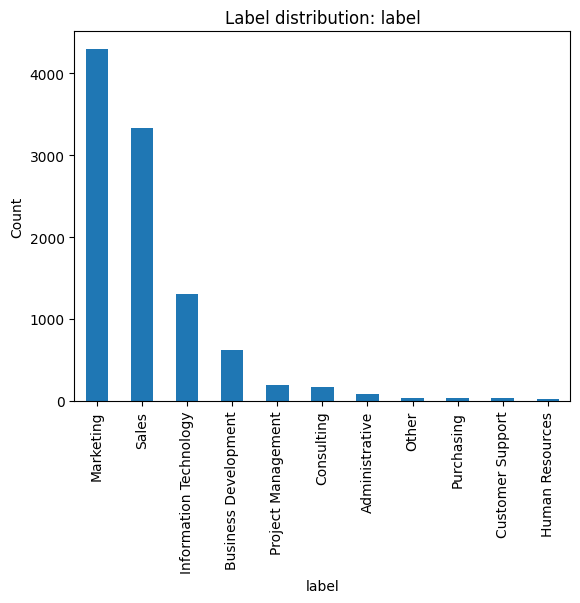

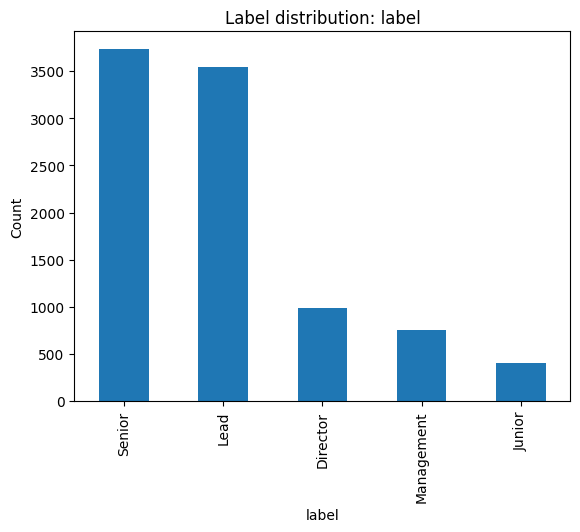

In [ ]:
#Imblance sichtbar machen:

import matplotlib.pyplot as plt

def plot_label_distribution(df, col):
    counts = df[col].value_counts()
    counts.plot(kind="bar")
    plt.title(f"Label distribution: {col}")
    plt.ylabel("Count")
    plt.show()

plot_label_distribution(df_1, "label")
plot_label_distribution(df_2, "label")

In [ ]:
#Dictionaries for Job and Seniority

import pandas as pd
import re
from pathlib import Path

dept_df = df_1
sen_df  = df_2

def find_label_column(df):
    # typische Kandidaten
    candidates = [c for c in df.columns if c.lower() in {"label","name","department","domain","seniority","class"}]
    if candidates:
        return candidates[0]
    # fallback: erste Spalte
    return df.columns[0]

def find_keywords_column(df):
    # typische Kandidaten
    candidates = [c for c in df.columns if c.lower() in {"keywords","keyword","terms","synonyms","synonym","patterns"}]
    if candidates:
        return candidates[0]
    # fallback: keine Keywords-Spalte
    return None

def split_keywords(x):
    """Akzeptiert 'a, b; c | d' -> ['a','b','c','d']"""
    if pd.isna(x):
        return []
    s = str(x).strip()
    if not s:
        return []
    parts = re.split(r"[,\|;/]+", s)
    return [p.strip().lower() for p in parts if p.strip()]

def build_label_dict(df):
    label_col = find_label_column(df)
    kw_col    = find_keywords_column(df)

    label_to_kws = {}
    for _, r in df.iterrows():
        label = str(r[label_col]).strip()
        if not label or label.lower() == "nan":
            continue
        kws = split_keywords(r[kw_col]) if kw_col else []
        label_to_kws[label] = kws
    return label_col, kw_col, label_to_kws

dept_label_col, dept_kw_col, DEPT_DICT = build_label_dict(dept_df)
sen_label_col,  sen_kw_col,  SEN_DICT  = build_label_dict(sen_df)

print("Department label col:", dept_label_col, "| keywords col:", dept_kw_col, "| n labels:", len(DEPT_DICT))
print("Seniority label col:",  sen_label_col,  "| keywords col:", sen_kw_col,  "| n labels:", len(SEN_DICT))
print("Example dept labels:", list(DEPT_DICT.keys())[:10])
print("Example seniority labels:", list(SEN_DICT.keys())[:10])


Department label col: label | keywords col: None | n labels: 11
Seniority label col: label | keywords col: None | n labels: 5
Example dept labels: ['Marketing', 'Project Management', 'Administrative', 'Business Development', 'Consulting', 'Human Resources', 'Information Technology', 'Other', 'Purchasing', 'Sales']
Example seniority labels: ['Junior', 'Senior', 'Lead', 'Management', 'Director']


In [ ]:
#Setup (Imports + Pfade) #JSON Files

import json
import re
from pathlib import Path

In [ ]:
import pandas as pd
data_path_ANNOTATED_JSON = 'https://raw.githubusercontent.com/Leo278V/Final-Assignment-PDS/refs/heads/Final-Assignment/linkedin-cvs-annotated.json?token=GHSAT0AAAAAADQCRM6XPLBTH6IX2ARWNFCY2KBGASQ'
df_3 = pd.read_json(data_path_ANNOTATED_JSON)
df_3.head()

,0,1,2,3,4,5,6,7,8,9,...,27,28,29,30,31,32,33,34,35,36
0,"{'organization': 'Depot4Design GmbH', 'linkedi...","{'organization': 'Depot4Design GmbH', 'linkedi...","{'organization': 'Depot4Design GmbH', 'linkedi...","{'organization': 'Depot4Design GmbH', 'linkedi...","{'organization': 'Depot4Design GmbH', 'linkedi...","{'organization': 'Nagel Car Group', 'linkedin'...",None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1,"{'organization': 'Computer Solutions', 'linked...","{'organization': 'Computer Solutions', 'linked...",{'organization': 'Texas A&M University-Corpus ...,{'organization': 'Texas A&M University-Corpus ...,{'organization': 'Texas A&M University at Qata...,{'organization': 'Texas A&M University at Qata...,"{'organization': 'Texas A&M Forest Service', '...","{'organization': 'MicroAge College Station', '...",None,None,...,None,None,None,None,None,None,None,None,None,None
2,"{'organization': 'Udo Weber', 'linkedin': 'htt...","{'organization': 'Med 360°', 'linkedin': 'http...","{'organization': 'Philips', 'linkedin': 'https...",None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
3,"{'organization': 'Grupo Viajes Kontiki.', 'lin...",{'organization': 'Air & Ground Operations Cons...,"{'organization': 'Viajes Oceano S.L.', 'linked...",{'organization': 'TDCS Travelport official par...,"{'organization': 'Smyland, Logitravel group', ...",{'organization': 'Confederación Española de Ag...,"{'organization': 'Vik Hotel Group', 'linkedin'...",None,None,None,...,None,None,None,None,None,None,None,None,None,None
4,{'organization': 'Himmelstalunds Utbildningsce...,"{'organization': 'ABC Kraften', 'linkedin': 'h...","{'organization': 'Trind AB', 'linkedin': '', '...","{'organization': 'Telia Company', 'linkedin': ...","{'organization': 'Telia Company', 'linkedin': ...","{'organization': 'TeliaSonera', 'linkedin': ''...","{'organization': 'Telia Communications', 'link...","{'organization': 'Telia AB', 'linkedin': '', '...",None,None,...,None,None,None,None,None,None,None,None,None,None


In [ ]:
data_path_UNANNOTATED_JSON = 'https://raw.githubusercontent.com/Leo278V/Final-Assignment-PDS/refs/heads/Final-Assignment/linkedin-cvs-not-annotated.json?token=GHSAT0AAAAAADQCRM6WVI57QRN37AGTDT362KBFYKA'
df_4 = pd.read_json(data_path_UNANNOTATED_JSON)
df_4.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,"{'organization': 'Keeping The Books, Bookkeepi...","{'organization': 'Playful Paws', 'linkedin': '...","{'organization': 'S&R services', 'linkedin': '...","{'organization': 'ABC Supply Co. Inc.', 'linke...","{'organization': 'MB Railways', 'linkedin': ''...","{'organization': 'Sysco', 'linkedin': 'https:/...","{'organization': 'UPS Freight', 'linkedin': 'h...","{'organization': 'Domino's Pizza', 'linkedin':...",None,None,None,None,None,None,None,None,None,None,None,None
1,"{'organization': 'Erste Bank und Sparkasse', '...","{'organization': 'DO & CO AG', 'linkedin': 'ht...",{'organization': 'WU (Vienna University of Eco...,"{'organization': 'Baker McKenzie', 'linkedin':...","{'organization': 'Deloitte', 'linkedin': 'http...","{'organization': 'Austrian Parliament', 'linke...","{'organization': 'UniCredit Bank Austria AG', ...",{'organization': 'Se2 Solutions Service & Secu...,{'organization': 'DC Bank AG (Diners Club Aust...,{'organization': 'Ludwig Boltzmann Institute f...,"{'organization': 'The University of Glasgow', ...",{'organization': 'ESW Consulting Wruss Zivilte...,"{'organization': 'University of Graz', 'linked...",None,None,None,None,None,None,None
2,"{'organization': 'Guido Meyer', 'linkedin': ''...","{'organization': 'Guido Meyer', 'linkedin': ''...",None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
3,"{'organization': 'Advicing', 'linkedin': '', '...",None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
4,"{'organization': 'Tradeware AG', 'linkedin': '...","{'organization': 'Smartec Services AG', 'linke...","{'organization': 'The DocuCollege Ltd.', 'link...","{'organization': 'The DocuCollege Ltd.', 'link...","{'organization': 'The DocuCollege Ltd.', 'link...","{'organization': '20 Minuten', 'linkedin': 'ht...","{'organization': 'Xerox', 'linkedin': 'https:/...","{'organization': 'AXEED Informatik AG', 'linke...",None,None,None,None,None,None,None,None,None,None,None,None


In [ ]:
#Annotated Data

import json, re
import pandas as pd
from pathlib import Path

# The original 'with open(ANNOTATED_JSON, ...)' was trying to read a DataFrame as a file.
# Instead, we directly process df_3 (which already holds the JSON data) into a list of dictionaries.

# Correctly transform df_3 into a list of profiles, where each profile is a list of positions
annotated_profiles = []
for _, row in df_3.iterrows():
    profile_positions = row.dropna().tolist()
    if profile_positions:
        annotated_profiles.append(profile_positions)
annotated = annotated_profiles

def parse_ym(s):
    if s is None:
        return (-1, -1)
    s = str(s).strip()
    m = re.fullmatch(r"(\d{4})-(\d{2})", s)
    if m:
        return (int(m.group(1)), int(m.group(2)))
    m = re.fullmatch(r"(\d{4})", s)
    if m:
        return (int(m.group(1)), 0)
    # fallback
    m = re.search(r"(\d{4})(?:-(\d{2}))?", s)
    if m:
        return (int(m.group(1)), int(m.group(2)) if m.group(2) else 0)
    return (-1, -1)

def pick_current_job(positions):
    active = [p for p in positions if str(p.get("status","")).upper() == "ACTIVE"]
    if not active:
        return None
    return sorted(active, key=lambda p: parse_ym(p.get("startDate")), reverse=True)[0]

def norm_text(*parts):
    txt = " ".join([str(p) for p in parts if p not in [None, "nan"]])
    return re.sub(r"\s+", " ", txt).strip()

rows = []
for pid, positions in enumerate(annotated):
    # Now 'positions' is correctly a list of dictionaries for a single profile
    if not isinstance(positions, list):
        continue # This should ideally not happen with the corrected 'annotated'

    cur = pick_current_job(positions)
    if cur is None:
        continue

    rows.append({
        "profile_id": pid,
        "job_title": cur.get("position"),
        "organization": cur.get("organization"),
        "startDate": cur.get("startDate"),
        "text": norm_text(cur.get("position"), cur.get("organization")),
        # labels (bei annotated vorhanden)
        "department_label": cur.get("department"),
        "seniority_label": cur.get("seniority"),
        # optionale Meta-Features
        "n_positions_total": len(positions),
        "n_active_positions": sum(1 for p in positions if str(p.get("status","")).upper() == "ACTIVE"),
    })

df = pd.DataFrame(rows)
print(df.shape)
print(df.head(3))
print(df[["department_label","seniority_label"]].isna().mean())

(478, 9)
   profile_id                job_title        organization startDate  \
0           0                Prokurist   Depot4Design GmbH   2019-08   
1           1      Solutions Architect  Computer Solutions   2024-03   
2           2  Medizintechnik Beratung           Udo Weber   2025-01   

                                     text        department_label  \
0             Prokurist Depot4Design GmbH                   Other   
1  Solutions Architect Computer Solutions  Information Technology   
2       Medizintechnik Beratung Udo Weber              Consulting   

  seniority_label  n_positions_total  n_active_positions  
0      Management                  6                   5  
1    Professional                  8                   1  
2    Professional                  3                   1  
department_label    0.0
seniority_label     0.0
dtype: float64


In [ ]:
#Model for Seniority & Department
#Schritt 2 – First ML-Modell (Baseline #2): TF-IDF + Logistic Regression


from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

def train_text_classifier(df, text_col, label_col):
    df2 = df.dropna(subset=[text_col, label_col]).copy()
    X = df2[text_col].astype(str)
    y = df2[label_col].astype(str)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.9)),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
    ])

    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)

    print(f"\n=== {label_col} ===")
    print(classification_report(y_te, pred))
    return model

dept_model = train_text_classifier(df, "text", "department_label")
sen_model  = train_text_classifier(df, "job_title", "seniority_label")



=== department_label ===
                        precision    recall  f1-score   support

        Administrative       0.00      0.00      0.00         2
  Business Development       0.67      1.00      0.80         4
            Consulting       1.00      0.67      0.80         6
      Customer Support       0.00      0.00      0.00         1
       Human Resources       0.25      0.33      0.29         3
Information Technology       0.60      0.55      0.57        11
             Marketing       0.25      0.50      0.33         4
                 Other       0.78      0.59      0.67        49
    Project Management       0.30      0.50      0.38         6
            Purchasing       0.50      0.50      0.50         2
                 Sales       0.38      0.38      0.38         8

              accuracy                           0.55        96
             macro avg       0.43      0.46      0.43        96
          weighted avg       0.64      0.55      0.58        96


=== senior

In [ ]:
#Schritt 3 – Predictions erzeugen (z.B. fürs unannotated später)

df["dept_pred"] = dept_model.predict(df["text"].astype(str))
df["sen_pred"]  = sen_model.predict(df["job_title"].astype(str))

df[["job_title","department_label","dept_pred","seniority_label","sen_pred"]].head(20)


,job_title,department_label,dept_pred,seniority_label,sen_pred
0,Prokurist,Other,Other,Management,Management
1,Solutions Architect,Information Technology,Information Technology,Professional,Professional
2,Medizintechnik Beratung,Consulting,Other,Professional,Professional
3,Director expansión de negocio.,Business Development,Business Development,Director,Director
4,"APL-ansvarig, samordning",Administrative,Other,Lead,Professional
5,Kaufmännischer Leiter,Sales,Sales,Lead,Lead
6,Lab-Supervisor,Other,Other,Lead,Professional
7,Human Resources Generalist,Human Resources,Human Resources,Professional,Professional
8,Managing Director,Other,Other,Management,Management
9,Set Lighting,Other,Other,Professional,Professional


#Projekt: Unannoted Pseudo Labeling - Active Job über Seniority und Department laufen lassen und diese gelabelten Daten extrahieren und dem annotated DF hinzufügen



In [10]:
#1) CSVs laden → Lookup bauen

import pandas as pd
import re

def norm(s: str) -> str:
    if s is None or (isinstance(s, float) and pd.isna(s)):
        return ""
    s = str(s).strip().lower()
    s = re.sub(r"\s+", " ", s)
    return s

dep_df = df_1   # columns: text, label
sen_df = df_2    # columns: text, label

dep_map = dict(zip(dep_df["text"].map(norm), dep_df["label"]))
sen_map = dict(zip(sen_df["text"].map(norm), sen_df["label"]))

def build_contains_list(df):
    pairs = [(norm(t), lbl) for t, lbl in zip(df["text"], df["label"]) if pd.notna(t)]
    pairs = [(t, lbl) for t, lbl in pairs if t]
    pairs.sort(key=lambda x: len(x[0]), reverse=True)
    return pairs

dep_contains = build_contains_list(dep_df)
sen_contains = build_contains_list(sen_df)

In [11]:
#2) Klassifierer: position → department/seniority (sonst n.a.)

def classify_position(position: str, na="n.a.", use_contains=True):
    key = norm(position)

    dep = dep_map.get(key)
    sen = sen_map.get(key)

    if use_contains and dep is None:
        for phrase, lbl in dep_contains:
            if phrase in key:
                dep = lbl
                break

    if use_contains and sen is None:
        for phrase, lbl in sen_contains:
            if phrase in key:
                sen = lbl
                break

    return (dep if dep is not None else na), (sen if sen is not None else na)


In [12]:
#3) ACTIVE Job finden (aus deiner Struktur)

def get_active_job(jobs):
    for j in jobs:
        if str(j.get("status", "")).upper() == "ACTIVE":
            return j
    return None


In [16]:
#4) unannotated erweitern (in-place) + Trefferquote messen

import pandas as pd
data_path_UNANNOTATED_JSON = 'https://raw.githubusercontent.com/Leo278V/Final-Assignment-PDS/refs/heads/main/linkedin-cvs-not-annotated.json?token=GHSAT0AAAAAADQCRM6WTX5X2GSQFW4ISSWY2KBMN4A'
df_4 = pd.read_json(data_path_UNANNOTATED_JSON)

# Correctly transform df_4 into a list of profiles, where each profile is a list of positions
unannotated_profiles = []
for _, row in df_4.iterrows():
    profile_positions = row.dropna().tolist()
    if profile_positions:
        unannotated_profiles.append(profile_positions)
unannotated = unannotated_profiles

def enrich_unannotated(unannotated, na="n.a.", use_contains=True):
    total = 0
    dep_hits = 0
    sen_hits = 0

    for jobs in unannotated:
        active = get_active_job(jobs)
        if not active:
            continue

        total += 1
        position = active.get("position", "")

        dep_pred, sen_pred = classify_position(position, na=na, use_contains=use_contains)

        # Speichere Predictions (nicht als "department"/"seniority", damit du Ground Truth nicht überschreibst)
        active["department_pred"] = dep_pred
        active["seniority_pred"]  = sen_pred

        dep_hits += (dep_pred != na)
        sen_hits += (sen_pred != na)

    stats = {
        "active_profiles": total,
        "dept_hit_rate": dep_hits / total if total else 0.0,
        "sen_hit_rate": sen_hits / total if total else 0.0,
    }
    return unannotated, stats

unannotated_enriched, stats = enrich_unannotated(unannotated, na="n.a.", use_contains=True)
stats

{'active_profiles': 314,
 'dept_hit_rate': 0.33121019108280253,
 'sen_hit_rate': 0.6592356687898089}

In [17]:
#5) Optional: als Trainings-DataFrame exportieren
def to_training_df(unannotated_enriched):
    rows = []
    for profile_idx, jobs in enumerate(unannotated_enriched):
        active = get_active_job(jobs)
        if not active:
            continue
        rows.append({
            "profile_idx": profile_idx,
            "organization": active.get("organization"),
            "position": active.get("position"),
            "department_pred": active.get("department_pred", "n.a."),
            "seniority_pred": active.get("seniority_pred", "n.a."),
            "linkedin": active.get("linkedin"),
            "startDate": active.get("startDate"),
            "endDate": active.get("endDate"),
        })
    return pd.DataFrame(rows)

train_df = to_training_df(unannotated_enriched)

# Beispiel: nur sichere pseudo-labels behalten
train_df_strict = train_df[
    (train_df["department_pred"] != "n.a.") &
    (train_df["seniority_pred"] != "n.a.")
].copy()

train_df.head(), train_df_strict.shape


(   profile_idx                    organization                position  \
 0            0  Keeping The Books, Bookkeeping              Bookkeeper   
 1            1        Erste Bank und Sparkasse  Strategy & Investments   
 2            2                     Guido Meyer       Corporate Auditor   
 3            4                    Tradeware AG       Marketing Manager   
 4            5               Monash University               Professor   
 
           department_pred seniority_pred  \
 0                    n.a.           n.a.   
 1                    n.a.           n.a.   
 2  Information Technology           n.a.   
 3               Marketing         Senior   
 4                    n.a.           n.a.   
 
                                             linkedin startDate endDate  
 0                                                      2023-03    None  
 1  https://www.linkedin.com/company/erste-bank-un...   2025-03    None  
 2                                                    

In [19]:
#Treffgenauigkeit prüfen:

total = len(train_df)

dept_assigned = (train_df["department_pred"] != "n.a.").sum()
sen_assigned  = (train_df["seniority_pred"]  != "n.a.").sum()

both_assigned = (
    (train_df["department_pred"] != "n.a.") &
    (train_df["seniority_pred"]  != "n.a.")
).sum()

print(f"Total Personen (ACTIVE): {total}")
print(f"Department zugeordnet:  {dept_assigned} ({dept_assigned/total:.1%})")
print(f"Seniority zugeordnet:   {sen_assigned} ({sen_assigned/total:.1%})")
print(f"Beides zugeordnet:      {both_assigned} ({both_assigned/total:.1%})")


Total Personen (ACTIVE): 314
Department zugeordnet:  104 (33.1%)
Seniority zugeordnet:   207 (65.9%)
Beides zugeordnet:      75 (23.9%)


In [21]:
display(train_df_strict.head(75))

,profile_idx,organization,position,department_pred,seniority_pred,linkedin,startDate,endDate
3,4,Tradeware AG,Marketing Manager,Marketing,Senior,https://www.linkedin.com/company/tradeware-ag,2020-07,None
6,8,ALSO Deutschland GmbH,Business Analyst,Business Development,Junior,https://www.linkedin.com/company/alsogroup,1992-06,None
7,10,Brandtner IT,Managementberater IT- und Governance,Consulting,Senior,,2024-03,None
16,21,r2b energy consulting GmbH,Mitglied der Geschäftsleitung,Information Technology,Lead,https://www.linkedin.com/company/r2b-energy-co...,2025-01,None
17,22,Owens Corning,"Global Marketing Director, Nonwovens",Marketing,Director,https://www.linkedin.com/company/owens-corning,2024-11,None
...,...,...,...,...,...,...,...,...
304,380,Hewlett Packard Enterprise,Head of Hybrid Cloud Solution Sales Germany,Sales,Lead,https://www.linkedin.com/company/hewlett-packa...,2024-11,None
307,383,Nestle,Project Manager Entwicklung /Lebensmittel,Project Management,Senior,https://www.linkedin.com/company/nestle-s-a-,1989-09,None
308,384,Freiberuflich,Consultant,Consulting,Senior,,2024-11,None
309,385,Random House,General Counsel / Leiter Rechtsabteilung,Information Technology,Lead,,2000,None


In [23]:
#Distribution of pseudo labelded data
#Overview of distribution of labeled data for department
#Is it changing the previous distribution for the annotated data set?
train_df_strict['department_pred'].value_counts()


,count
department_pred,
Information Technology,33
Sales,12
Marketing,8
Consulting,8
Project Management,6
Business Development,3
Administrative,2
Human Resources,2
Purchasing,1


In [25]:
#Overview of distribution of labeled data for seniority
train_df_strict['seniority_pred'].value_counts()


,count
seniority_pred,
Senior,33
Lead,26
Management,7
Director,5
Junior,4


Additional Rule for improved Assignment Seniority for those who are not assigned by the first rule: If Active Job Start Date is below 3 years than Junior Level.
Open Question: How to distinguqish between Managment and Lead? Number of Jobs - Job Description?